In [6]:
import os
import sys
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split


THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))
DATA_DIR = os.path.abspath(os.path.join(TAGGING_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import model as model_mod  # noqa: E402
import importlib  # noqa: E402
importlib.reload(tool)  # noqa: E402
importlib.reload(model_mod)  # noqa: E402
from model import ParticleTransformerKD, SharedEncoderUnsmearClassifier  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_transformer_sharedencoder_delta_gate_joint'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
METRICS_DIR = os.path.join(OUT_DIR, 'metrics')
SHARED_BASELINE_DIR = os.path.join(MODULE_DIR, 'runs', 'shared_offline_hlt_baselines')
SHARED_BASELINE_CKPT_DIR = os.path.join(SHARED_BASELINE_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(METRICS_DIR)
tool.ensure_dir(SHARED_BASELINE_CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(DATA_DIR, 'test.h5'),
    'n_jets': 200000,
    'max_particles': 100,
    'feature_kind': '7d',
    'load_shared_baselines': True,
    'load_joint_model': False,
    'joint_model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
        'unsmear_decoder_layers': 2,
        'unsmear_decoder_heads': 8,
        'unsmear_decoder_ff_dim': 512,
        'unsmear_decoder_dropout': 0.1,
        'return_reco': True,
        'add_mask_channel': False,
        'mask_output': True,
        'use_positional_embedding': False,
        'max_seq_len': 128,
        'cls_use_delta_fusion': True,
        'cls_detach_delta_for_cls': False,
        'cls_gate_hidden_dim': 128,
        'cls_gate_init_bias': -2.0,
        'cls_alpha_init': 0.05,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0,
        'pt_threshold_hlt': 0,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'kd': {
        'enable': True,
        'temperature': 2.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0,
    },
    'training': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
        'early_stop_metric': 'val_auc_weighted',
        'use_sample_weight_for_all_losses': True,
        'joint_unsmear_weight': 2.4,
        'joint_cls_weight': 0.6,
        'joint_phys_weight': 0.0,
        'feature_loss_weights': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
        'resmear_each_epoch_baselines': True,
        'resmear_each_epoch_joint': True,
        'resmear_seed_stride': 1,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['joint_model']['input_dim'] = len(feat_names)
CONFIG['joint_model']['max_seq_len'] = int(CONFIG['max_particles'])
CONFIG['tagger']['input_dim'] = len(feat_names)

feature_loss_weights = np.asarray(CONFIG['training']['feature_loss_weights'], dtype=np.float32)
if feature_loss_weights.shape[0] != len(feat_names):
    raise ValueError(
        f"Expected {len(feat_names)} feature weights for {CONFIG['feature_kind']}, got {feature_loss_weights.shape[0]}"
    )
CONFIG['training']['feature_loss_weights'] = feature_loss_weights.tolist()
CONFIG['training']['use_sample_weight_for_all_losses'] = bool(
    CONFIG['training'].get('use_sample_weight_for_all_losses', True)
)

config_path = os.path.join(OUT_DIR, 'config.json')
tool.save_config(CONFIG, config_path)
print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)
print('Feature loss weights:', dict(zip(feat_names, np.round(feature_loss_weights, 4))))
print('Joint physical consistency weight:', float(CONFIG['training']['joint_phys_weight']))
print('Use sample weight for all losses:', bool(CONFIG['training']['use_sample_weight_for_all_losses']))
print('Delta fusion enabled:', bool(CONFIG['joint_model']['cls_use_delta_fusion']))
print('Detach delta for classifier:', bool(CONFIG['joint_model']['cls_detach_delta_for_cls']))
print('Gate hidden dim:', int(CONFIG['joint_model']['cls_gate_hidden_dim']))
print('Gate init bias:', float(CONFIG['joint_model']['cls_gate_init_bias']))
print('Alpha init:', float(CONFIG['joint_model']['cls_alpha_init']))


Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0324_feat_weight
Feature kind: 7d feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']
Feature loss weights: {'dEta': np.float32(1.0), 'dPhi': np.float32(1.0), 'log_pt': np.float32(1.0), 'log_E': np.float32(1.0), 'log_pt_rel': np.float32(1.0), 'log_E_rel': np.float32(1.0), 'dR': np.float32(1.0)}
Joint physical consistency weight: 0.0
Use sample weight for all losses: True


In [3]:
# Load the raw constituents and build the offline / HLT views
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0
print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])
_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)
feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

x_joint = feat_hlt_std.copy()
y_joint = feat_off_std.copy()
x_joint[~common_mask] = 0.0
y_joint[~common_mask] = 0.0

train_const_raw = constituents_raw[train_idx]
train_mask_raw = mask_raw[train_idx]

print('Offline/HLT feature shape:', feat_off_std.shape, feat_hlt_std.shape)
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))
print('Common-mask fraction:', float(common_mask.mean()))
print('Feat means:', np.round(feat_means, 4))
print('Feat stds :', np.round(feat_stds, 4))
print('Baseline epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)))
print('Joint epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_joint', False)))


Raw: (200000, 100, 4) mask: (200000, 100)
Signal: 99836 Bkg: 100164
Split: train=140,000 val=30,000 test=30,000
Offline/HLT feature shape: (200000, 100, 7) (200000, 100, 7)
Mask identical: True
Common-mask fraction: 0.5429243
Feat means: [-2.0000e-04 -1.0000e-04  8.7940e+00  9.0840e+00 -5.2585e+00 -5.2701e+00
  2.2250e-01]
Feat stds : [0.2121 0.2173 1.5182 1.5217 1.4919 1.4935 0.2067]
Baseline epoch resmear enabled: True
Joint epoch resmear enabled: True


In [4]:
# Build the datasets and loaders
BS = int(CONFIG['training']['batch_size'])
train_ds_hlt = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds_hlt = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds_hlt = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

train_ds_joint = tool.JointJetDataset(
    x_joint[train_idx],
    y_joint[train_idx],
    common_mask[train_idx],
    labels[train_idx],
    weights[train_idx],
)
val_ds_joint = tool.JointJetDataset(
    x_joint[val_idx],
    y_joint[val_idx],
    common_mask[val_idx],
    labels[val_idx],
    weights[val_idx],
)
test_ds_joint = tool.JointJetDataset(
    x_joint[test_idx],
    y_joint[test_idx],
    common_mask[test_idx],
    labels[test_idx],
    weights[test_idx],
)

train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS, shuffle=False)

train_loader_joint = DataLoader(train_ds_joint, batch_size=BS, shuffle=True, drop_last=True)
val_loader_joint = DataLoader(val_ds_joint, batch_size=BS, shuffle=False)
test_loader_joint = DataLoader(test_ds_joint, batch_size=BS, shuffle=False)


def make_epoch_hlt_train_loader(epoch: int):
    return tool.make_epoch_hlt_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        feat_off_train=feat_off_std[train_idx],
        off_mask_train=off_mask[train_idx],
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_feat_hlt_train=feat_hlt_std[train_idx],
        fixed_hlt_mask_train=hlt_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)),
        clip=10.0,
    )


def make_epoch_joint_train_loader(epoch: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


In [7]:
# Train the offline teacher, HLT / HLT+KD baselines, and the joint shared-encoder models (with / without KD)
train_cfg = CONFIG['training']
kd_cfg = CONFIG['kd']
use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
joint_feature_loss_weights = np.asarray(train_cfg['feature_loss_weights'], dtype=np.float32)
hlt_train_loader_factory = make_epoch_hlt_train_loader if bool(train_cfg.get('resmear_each_epoch_baselines', False)) else None
joint_train_loader_factory = make_epoch_joint_train_loader if bool(train_cfg.get('resmear_each_epoch_joint', True)) else None

epoch_metrics_paths = {
    'teacher_off': os.path.join(METRICS_DIR, 'teacher_off_epoch_metrics.csv'),
    'student_hlt': os.path.join(METRICS_DIR, 'student_hlt_epoch_metrics.csv'),
    'hlt_kd': os.path.join(METRICS_DIR, 'hlt_kd_epoch_metrics.csv'),
    'joint_no_kd': os.path.join(METRICS_DIR, 'joint_no_kd_epoch_metrics.csv'),
    'joint_with_kd': os.path.join(METRICS_DIR, 'joint_with_kd_epoch_metrics.csv'),
}

teacher = ParticleTransformerKD(**CONFIG['tagger']).to(device)
teacher_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'teacher_offline.pt')
teacher = tool.train_or_load_standard_model(
    'Teacher(OFF_FULL)',
    teacher,
    teacher_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    feat_key='off',
    mask_key='mask_off',
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    early_stop_metric=str(train_cfg['early_stop_metric']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    epoch_metrics_path=epoch_metrics_paths['teacher_off'],
)

student_hlt = ParticleTransformerKD(**CONFIG['tagger']).to(device)
student_hlt_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'student_hlt.pt')
student_hlt = tool.train_or_load_standard_model(
    'Student(HLT)',
    student_hlt,
    student_hlt_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    feat_key='hlt',
    mask_key='mask_hlt',
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    early_stop_metric=str(train_cfg['early_stop_metric']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    train_loader_factory=hlt_train_loader_factory,
    epoch_metrics_path=epoch_metrics_paths['student_hlt'],
)

student_hlt_kd = ParticleTransformerKD(**CONFIG['tagger']).to(device)
student_hlt_kd_ckpt = os.path.join(SHARED_BASELINE_CKPT_DIR, 'student_hlt_kd.pt')
student_hlt_kd = tool.train_or_load_kd_standard_model(
    'Student(HLT)+KD',
    student_hlt_kd,
    teacher,
    student_hlt_kd_ckpt,
    train_loader_hlt,
    val_loader_hlt,
    device=device,
    allow_load=bool(CONFIG.get('load_shared_baselines', True)),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    early_stop_metric=str(train_cfg['early_stop_metric']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    train_loader_factory=hlt_train_loader_factory,
    epoch_metrics_path=epoch_metrics_paths['hlt_kd'],
)

joint_model_no_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
joint_ckpt_no_kd = os.path.join(CKPT_DIR, 'joint_sharedencoder_no_kd.pt')
joint_model_no_kd = tool.train_or_load_joint_model(
    'JointSharedEncoder(HLT,no_kd)',
    joint_model_no_kd,
    joint_ckpt_no_kd,
    train_loader_joint,
    val_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_means=feat_means,
    feat_stds=feat_stds,
    feature_loss_weights=joint_feature_loss_weights,
    joint_phys_weight=float(train_cfg['joint_phys_weight']),
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    early_stop_metric=str(train_cfg['early_stop_metric']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    teacher=teacher,
    use_kd=False,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    allow_load=bool(CONFIG.get('load_joint_model', False)),
    train_loader_factory=joint_train_loader_factory,
    epoch_metrics_path=epoch_metrics_paths['joint_no_kd'],
)

joint_model_with_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
joint_ckpt_with_kd = os.path.join(CKPT_DIR, 'joint_sharedencoder_with_kd.pt')
joint_model_with_kd = tool.train_or_load_joint_model(
    'JointSharedEncoder(HLT,with_kd)',
    joint_model_with_kd,
    joint_ckpt_with_kd,
    train_loader_joint,
    val_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_means=feat_means,
    feat_stds=feat_stds,
    feature_loss_weights=joint_feature_loss_weights,
    joint_phys_weight=float(train_cfg['joint_phys_weight']),
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    lr=float(train_cfg['lr']),
    weight_decay=float(train_cfg['weight_decay']),
    warmup_epochs=int(train_cfg['warmup_epochs']),
    epochs=int(train_cfg['epochs']),
    patience=int(train_cfg['patience']),
    early_stop_metric=str(train_cfg['early_stop_metric']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    teacher=teacher,
    use_kd=True,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    allow_load=bool(CONFIG.get('load_joint_model', False)),
    train_loader_factory=joint_train_loader_factory,
    epoch_metrics_path=epoch_metrics_paths['joint_with_kd'],
)

auc_teacher, auc_teacher_w, p_teacher, y_true, w_true = tool.evaluate(
    teacher,
    test_loader_hlt,
    device,
    'off',
    'mask_off',
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
)
auc_hlt, auc_hlt_w, p_hlt, _, _ = tool.evaluate(
    student_hlt,
    test_loader_hlt,
    device,
    'hlt',
    'mask_hlt',
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
)
hlt_kd_test = tool.eval_kd_student(
    student_hlt_kd,
    teacher,
    test_loader_hlt,
    device,
    {'kd': {'temperature': float(kd_cfg['temperature']), 'alpha_kd': float(kd_cfg['alpha_kd']), 'alpha_attn': float(kd_cfg['alpha_attn'])}},
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
)
auc_hlt_kd = float(hlt_kd_test['auc'])
auc_hlt_kd_w = float(hlt_kd_test['auc_weighted'])
p_hlt_kd = np.asarray(hlt_kd_test['preds'])

joint_test_no_kd = tool.eval_joint_model(
    joint_model_no_kd,
    test_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_means=feat_means,
    feat_stds=feat_stds,
    feature_loss_weights=joint_feature_loss_weights,
    joint_phys_weight=float(train_cfg['joint_phys_weight']),
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    teacher=teacher,
    use_kd=False,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
)

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loaded checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\shared_offline_hlt_baselines\ckpts\teacher_offline.pt
[Teacher(OFF_FULL)] Epoch-metrics table not found for the loaded checkpoint. Rerun training with loading disabled to regenerate it.
Loaded checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\shared_offline_hlt_baselines\ckpts\student_hlt.pt
[Student(HLT)] Epoch-metrics table not found for the loaded checkpoint. Rerun training with loading disabled to regenerate it.
Loaded checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\shared_offline_hlt_baselines\ckpts\student_hlt_kd.pt
[Student(HLT)+KD] Epoch-metrics table not found for the loaded checkpoint. Rerun training with loading disabled to regenerate it.
[Student(HLT)+KD] Gradient probe tables not found for the loaded checkpoint. Rerun training with loading disabled to regenerate them.
Loaded checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0324_fe

Teacher(OFF_FULL) AUC=0.94407, weighted AUC=0.93515
Student(HLT) AUC=0.92166, weighted AUC=0.90613
Student(HLT)+KD AUC=0.92269, weighted AUC=0.90160
Student(HLT)+KD test total loss=1.23453
Student(HLT)+KD test hard loss=0.41416
Student(HLT)+KD test kd loss=2.05491
Student(HLT)+KD test attn loss=0.00000
JointSharedEncoder(HLT,no_kd) AUC=0.91901, weighted AUC=0.91108
JointSharedEncoder(HLT,with_kd) AUC=0.92644, weighted AUC=0.91465
Joint(no_kd) test unsmear loss=0.03322
Joint(with_kd) test unsmear loss=0.03300
Joint(no_kd) test cls hard loss=0.38634
Joint(with_kd) test cls hard loss=0.38774
Joint(with_kd) test cls kd loss=2.06860
Joint(with_kd) test cls attn loss=0.00000
Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0324_feat_weight\figs\sharedencoder_joint_downstream_roc_logfpr_5lines.png


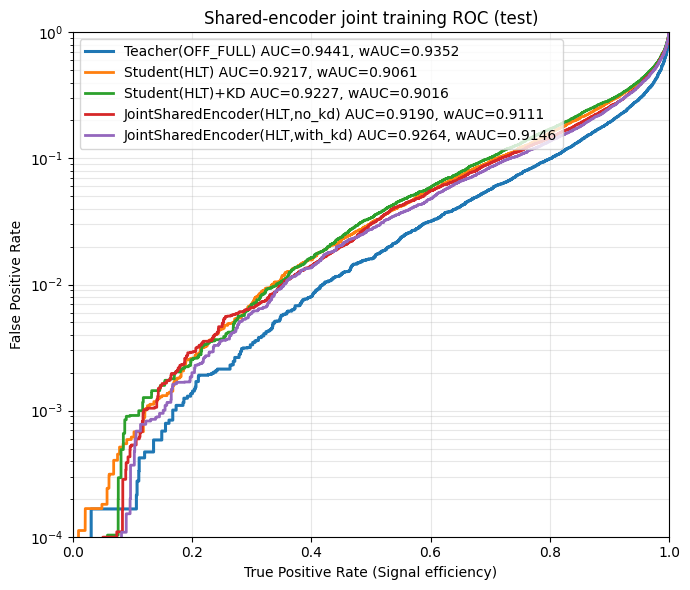

Saved table: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder0324_feat_weight\roc_operating_points_joint_with_kd.csv


,Metric,Teacher,HLT Baseline,joint_with_kd,Offline-HLT Gap Recovery
0,FPR @ 30%TPR,0.3256%,0.6963%,0.5936%,27.71%
1,FPR @ 50%TPR,1.5936%,3.0435%,2.7379%,21.07%


In [10]:
use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
auc_joint_no_kd = float(joint_test_no_kd['auc'])
auc_joint_no_kd_w = float(joint_test_no_kd['auc_weighted'])
p_joint_no_kd = np.asarray(joint_test_no_kd['preds'])
y_joint_true = np.asarray(joint_test_no_kd['labels'])
w_joint_true = np.asarray(joint_test_no_kd['weights'])

joint_test_with_kd = tool.eval_joint_model(
    joint_model_with_kd,
    test_loader_joint,
    device=device,
    feat_names=feat_names,
    feat_means=feat_means,
    feat_stds=feat_stds,
    feature_loss_weights=joint_feature_loss_weights,
    joint_phys_weight=float(train_cfg['joint_phys_weight']),
    joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
    joint_cls_weight=float(train_cfg['joint_cls_weight']),
    teacher=teacher,
    use_kd=True,
    kd_temperature=float(kd_cfg['temperature']),
    kd_alpha=float(kd_cfg['alpha_kd']),
    kd_alpha_attn=float(kd_cfg['alpha_attn']),
    use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
)
auc_joint_with_kd = float(joint_test_with_kd['auc'])
auc_joint_with_kd_w = float(joint_test_with_kd['auc_weighted'])
p_joint_with_kd = np.asarray(joint_test_with_kd['preds'])

print(f'Teacher(OFF_FULL) AUC={auc_teacher:.5f}, weighted AUC={auc_teacher_w:.5f}')
print(f'Student(HLT) AUC={auc_hlt:.5f}, weighted AUC={auc_hlt_w:.5f}')
print(f'Student(HLT)+KD AUC={auc_hlt_kd:.5f}, weighted AUC={auc_hlt_kd_w:.5f}')
print(f'Student(HLT)+KD test total loss={hlt_kd_test["total"]:.5f}')
print(f'Student(HLT)+KD test hard loss={hlt_kd_test["hard"]:.5f}')
print(f'Student(HLT)+KD test kd loss={hlt_kd_test["kd"]:.5f}')
print(f'Student(HLT)+KD test attn loss={hlt_kd_test["attn"]:.5f}')
print(f'JointSharedEncoder(HLT,no_kd) AUC={auc_joint_no_kd:.5f}, weighted AUC={auc_joint_no_kd_w:.5f}')
print(f'JointSharedEncoder(HLT,with_kd) AUC={auc_joint_with_kd:.5f}, weighted AUC={auc_joint_with_kd_w:.5f}')
print(f'Joint(no_kd) test unsmear loss={joint_test_no_kd["unsmear_total"]:.5f}')
print(f'Joint(with_kd) test unsmear loss={joint_test_with_kd["unsmear_total"]:.5f}')
print(f'Joint(no_kd) test cls hard loss={joint_test_no_kd["cls_hard_total"]:.5f}')
print(f'Joint(with_kd) test cls hard loss={joint_test_with_kd["cls_hard_total"]:.5f}')
print(f'Joint(with_kd) test cls kd loss={joint_test_with_kd["cls_kd_total"]:.5f}')
print(f'Joint(with_kd) test cls attn loss={joint_test_with_kd["cls_attn_total"]:.5f}')
print(f'Joint(no_kd) gate mean/std={joint_test_no_kd["gate_mean"]:.4f}/{joint_test_no_kd["gate_std"]:.4f}, alpha={joint_test_no_kd["alpha"]:.4f}')
print(f'Joint(with_kd) gate mean/std={joint_test_with_kd["gate_mean"]:.4f}/{joint_test_with_kd["gate_std"]:.4f}, alpha={joint_test_with_kd["alpha"]:.4f}')

roc_sample_weight_hlt = w_true if use_sample_weight_for_all_losses else None
roc_sample_weight_hlt_kd = np.asarray(hlt_kd_test['weights']) if use_sample_weight_for_all_losses else None
roc_sample_weight_joint = w_joint_true if use_sample_weight_for_all_losses else None

fpr_teacher, tpr_teacher, _, _ = tool.compute_roc(y_true, p_teacher, sample_weight=roc_sample_weight_hlt)
fpr_hlt, tpr_hlt, _, _ = tool.compute_roc(y_true, p_hlt, sample_weight=roc_sample_weight_hlt)
fpr_hlt_kd, tpr_hlt_kd, _, _ = tool.compute_roc(y_true, p_hlt_kd, sample_weight=roc_sample_weight_hlt_kd)
fpr_joint_no_kd, tpr_joint_no_kd, _, _ = tool.compute_roc(y_joint_true, p_joint_no_kd, sample_weight=roc_sample_weight_joint)
fpr_joint_with_kd, tpr_joint_with_kd, _, _ = tool.compute_roc(y_joint_true, p_joint_with_kd, sample_weight=roc_sample_weight_joint)

ROC_TABLE_RECO_LABEL = 'joint_with_kd'
ROC_TABLE_RECO_NAME = 'joint_with_kd'
roc_table_curves = {
    'teacher': (tpr_teacher, fpr_teacher),
    'hlt_baseline': (tpr_hlt, fpr_hlt),
    'joint_no_kd': (tpr_joint_no_kd, fpr_joint_no_kd),
    'joint_with_kd': (tpr_joint_with_kd, fpr_joint_with_kd),
}


def _fpr_at_target_tpr(tpr: np.ndarray, fpr: np.ndarray, target_tpr: float) -> float:
    tpr = np.asarray(tpr, dtype=np.float64)
    fpr = np.asarray(fpr, dtype=np.float64)
    order = np.argsort(tpr)
    tpr_sorted = tpr[order]
    fpr_sorted = fpr[order]
    tpr_unique, unique_idx = np.unique(tpr_sorted, return_index=True)
    fpr_unique = fpr_sorted[unique_idx]
    return float(np.interp(float(target_tpr), tpr_unique, fpr_unique))


roc_table_rows = []
for target_tpr in [0.30, 0.50]:
    teacher_fpr = _fpr_at_target_tpr(*roc_table_curves['teacher'], target_tpr)
    baseline_fpr = _fpr_at_target_tpr(*roc_table_curves['hlt_baseline'], target_tpr)
    reco_fpr = _fpr_at_target_tpr(*roc_table_curves[ROC_TABLE_RECO_NAME], target_tpr)
    denom = baseline_fpr - teacher_fpr
    recovery = np.nan if abs(denom) < 1e-12 else (baseline_fpr - reco_fpr) / denom
    roc_table_rows.append({
        'Metric': f'FPR @ {int(round(target_tpr * 100))}%TPR',
        'Teacher': teacher_fpr,
        'HLT Baseline': baseline_fpr,
        ROC_TABLE_RECO_LABEL: reco_fpr,
        'Offline-HLT Gap Recovery': recovery,
    })

import pandas as pd

roc_operating_df = pd.DataFrame(roc_table_rows)
roc_operating_df_display = roc_operating_df.copy()
for col in ['Teacher', 'HLT Baseline', ROC_TABLE_RECO_LABEL]:
    roc_operating_df_display[col] = roc_operating_df_display[col].map(lambda x: f'{100.0 * float(x):.4f}%')
roc_operating_df_display['Offline-HLT Gap Recovery'] = roc_operating_df_display['Offline-HLT Gap Recovery'].map(
    lambda x: 'nan' if pd.isna(x) else f'{100.0 * float(x):.2f}%'
)

plt.figure(figsize=(7, 6))
plt.semilogy(tpr_teacher, np.clip(fpr_teacher, 1e-6, 1.0), lw=2.2, label=f'Teacher(OFF_FULL) AUC={auc_teacher:.4f}, wAUC={auc_teacher_w:.4f}')
plt.semilogy(tpr_hlt, np.clip(fpr_hlt, 1e-6, 1.0), lw=2.0, label=f'Student(HLT) AUC={auc_hlt:.4f}, wAUC={auc_hlt_w:.4f}')
plt.semilogy(tpr_hlt_kd, np.clip(fpr_hlt_kd, 1e-6, 1.0), lw=2.0, label=f'Student(HLT)+KD AUC={auc_hlt_kd:.4f}, wAUC={auc_hlt_kd_w:.4f}')
plt.semilogy(tpr_joint_no_kd, np.clip(fpr_joint_no_kd, 1e-6, 1.0), lw=2.0, label=f'JointSharedEncoder(HLT,no_kd) AUC={auc_joint_no_kd:.4f}, wAUC={auc_joint_no_kd_w:.4f}')
plt.semilogy(tpr_joint_with_kd, np.clip(fpr_joint_with_kd, 1e-6, 1.0), lw=2.0, label=f'JointSharedEncoder(HLT,with_kd) AUC={auc_joint_with_kd:.4f}, wAUC={auc_joint_with_kd_w:.4f}')
plt.xlabel('True Positive Rate (Signal efficiency)')
plt.ylabel('False Positive Rate')
plt.title('Shared-encoder joint training ROC (test)')
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

roc_out = os.path.join(FIG_DIR, 'sharedencoder_joint_downstream_roc_logfpr_5lines.png')
plt.savefig(roc_out, dpi=180, bbox_inches='tight')
print('Saved figure:', roc_out)
plt.show()

roc_table_out = os.path.join(OUT_DIR, f'roc_operating_points_{ROC_TABLE_RECO_NAME}.csv')
roc_operating_df.to_csv(roc_table_out, index=False)
print('Saved table:', roc_table_out)
try:
    from IPython.display import display
    display(roc_operating_df_display)
except Exception:
    print(roc_operating_df_display.to_string(index=False))


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dEta.png


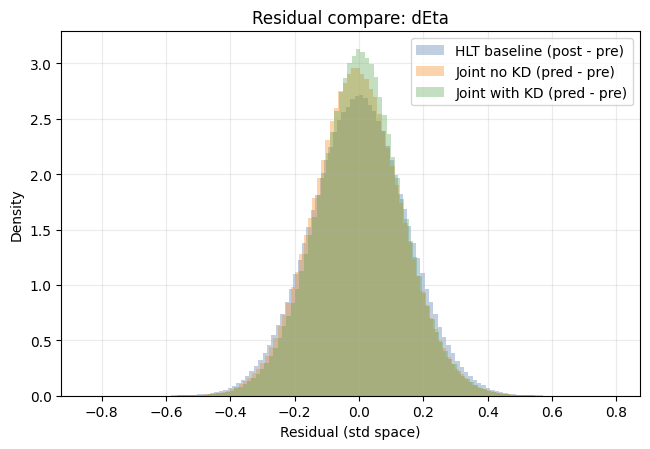

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dPhi.png


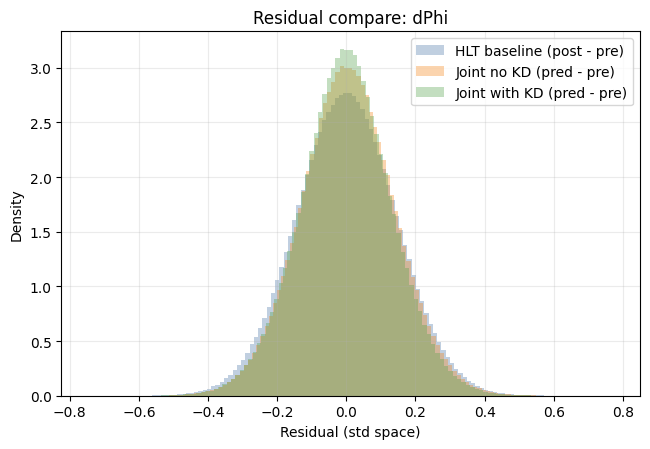

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt.png


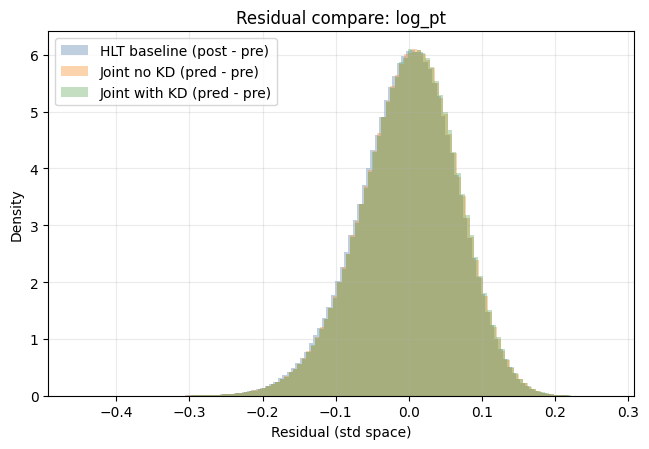

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E.png


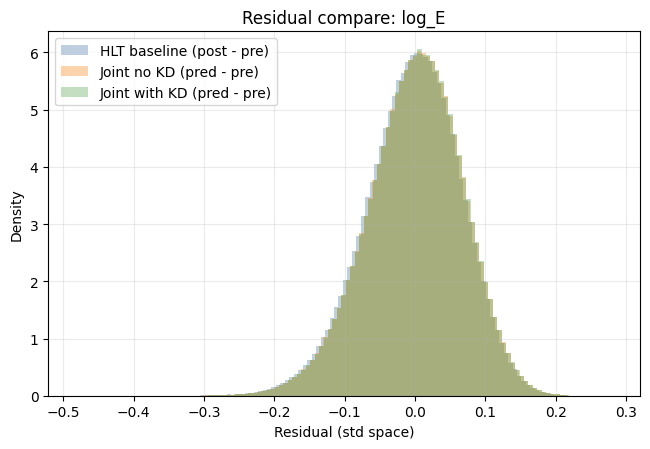

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_pt_rel.png


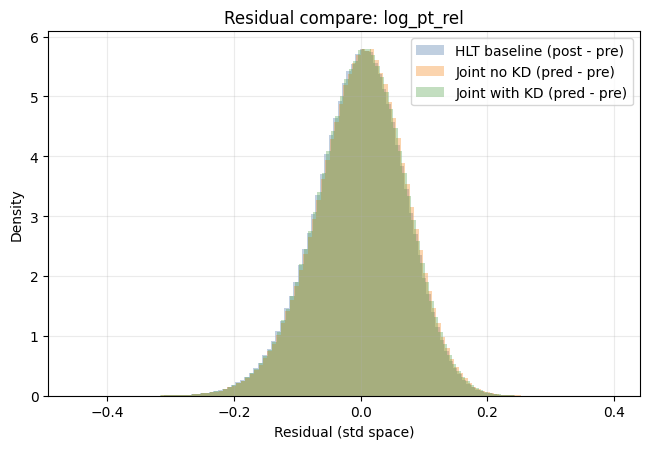

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_log_E_rel.png


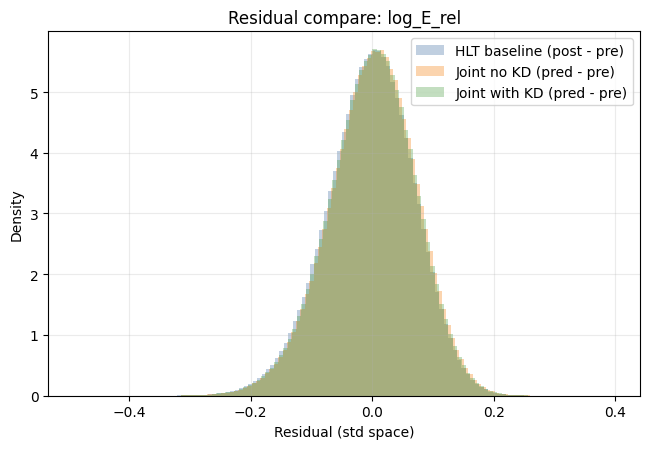

Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint\runs\unsmear_transformer_sharedencoder\figs\joint_reco_residual_compare_dR.png


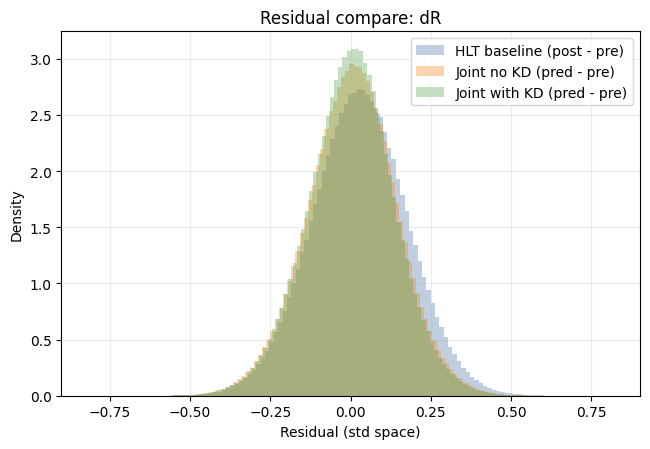


Metrics summary (std space) | split=test | n_tokens=1630900
   feature        method      bias      mae     rmse  abs_p50  abs_p90  abs_p99
      dEta           hlt -0.000556 0.118285 0.148658 0.099482 0.244542 0.385490
      dEta   joint_no_kd -0.005718 0.110289 0.139295 0.091970 0.229416 0.366883
      dEta joint_with_kd  0.002483 0.106326 0.135184 0.087550 0.223087 0.361525
      dPhi           hlt -0.000172 0.115474 0.145006 0.097246 0.238573 0.375467
      dPhi   joint_no_kd  0.004244 0.107649 0.135959 0.089735 0.224016 0.357593
      dPhi joint_with_kd -0.000840 0.104027 0.132105 0.085850 0.217998 0.351853
    log_pt           hlt -0.003360 0.052877 0.066770 0.044331 0.108811 0.177613
    log_pt   joint_no_kd -0.000090 0.052825 0.066539 0.044479 0.108500 0.175295
    log_pt joint_with_kd  0.000221 0.052801 0.066492 0.044469 0.108455 0.175047
     log_E           hlt -0.003796 0.053589 0.067663 0.044937 0.110348 0.179946
     log_E   joint_no_kd -0.000122 0.053506 0.067380 0.0450

,feature,method,bias,mae,rmse,abs_p50,abs_p90,abs_p99
0,dEta,hlt,-0.000556,0.118285,0.148658,0.099482,0.244542,0.385490
1,dEta,joint_no_kd,-0.005718,0.110289,0.139295,0.091970,0.229416,0.366883
2,dEta,joint_with_kd,0.002483,0.106326,0.135184,0.087550,0.223087,0.361525
3,dPhi,hlt,-0.000172,0.115474,0.145006,0.097246,0.238573,0.375467
4,dPhi,joint_no_kd,0.004244,0.107649,0.135959,0.089735,0.224016,0.357593
5,dPhi,joint_with_kd,-0.000840,0.104027,0.132105,0.085850,0.217998,0.351853
6,log_pt,hlt,-0.003360,0.052877,0.066770,0.044331,0.108811,0.177613
7,log_pt,joint_no_kd,-0.000090,0.052825,0.066539,0.044479,0.108500,0.175295
8,log_pt,joint_with_kd,0.000221,0.052801,0.066492,0.044469,0.108455,0.175047
9,log_E,hlt,-0.003796,0.053589,0.067663,0.044937,0.110348,0.179946


In [7]:
# Visualize unsmear reconstruction performance on the test set
import pandas as pd


@torch.no_grad()
def predict_joint_reco(model, loader):
    model.eval()
    outs = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        reco, _logits = model(x, m)
        outs.append(reco.detach().cpu().numpy())
    return np.concatenate(outs, axis=0)


def metric_dict(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {
            'bias': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'abs_p50': np.nan,
            'abs_p90': np.nan,
            'abs_p99': np.nan,
        }
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'abs_p50': float(np.quantile(abs_r, 0.50)),
        'abs_p90': float(np.quantile(abs_r, 0.90)),
        'abs_p99': float(np.quantile(abs_r, 0.99)),
    }


def maybe_wrap_residual(name: str, feat_idx: int, residual: np.ndarray) -> np.ndarray:
    if name == 'dPhi':
        sc = float(feat_stds[feat_idx])
        return tool.wrap_dphi_np(residual * sc) / sc
    return residual


pred_joint_no_kd_reco = predict_joint_reco(joint_model_no_kd, test_loader_joint)
pred_joint_with_kd_reco = predict_joint_reco(joint_model_with_kd, test_loader_joint)

x_test_std = x_joint[test_idx]
y_test_std = y_joint[test_idx]
mask_test = common_mask[test_idx]

residual_sources = {
    'hlt': x_test_std - y_test_std,
    'joint_no_kd': pred_joint_no_kd_reco - y_test_std,
    'joint_with_kd': pred_joint_with_kd_reco - y_test_std,
}
plot_labels = {
    'hlt': 'HLT baseline (post - pre)',
    'joint_no_kd': 'Joint no KD (pred - pre)',
    'joint_with_kd': 'Joint with KD (pred - pre)',
}
plot_colors = {
    'hlt': '#4C78A8',
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}

metrics_rows = []
for feat_idx, feat_name in enumerate(feat_names):
    plt.figure(figsize=(6.6, 4.6))
    for method_name in ['hlt', 'joint_no_kd', 'joint_with_kd']:
        residual = residual_sources[method_name][..., feat_idx][mask_test]
        residual = maybe_wrap_residual(feat_name, feat_idx, residual)
        plt.hist(
            residual,
            bins=120,
            density=True,
            alpha=0.35,
            label=plot_labels[method_name],
            color=plot_colors[method_name],
        )
        mm = metric_dict(residual)
        metrics_rows.append({
            'feature': feat_name,
            'method': method_name,
            **mm,
        })

    plt.title(f'Residual compare: {feat_name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'joint_reco_residual_compare_{feat_name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']]

print()
print('=' * 100)
print(f'Metrics summary (std space) | split=test | n_tokens={int(mask_test.sum())}')
print('=' * 100)
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

metrics_out = os.path.join(OUT_DIR, 'joint_reco_metrics_summary_test.csv')
metrics_df.to_csv(metrics_out, index=False)
print('Saved table:', metrics_out)

try:
    from IPython.display import display
    display(metrics_df)
except Exception:
    pass


In [ ]:
# Visualize gate and alpha trends across epochs.
import pandas as pd

joint_metric_paths = {
    'joint_no_kd': os.path.join(METRICS_DIR, 'joint_no_kd_epoch_metrics.csv'),
    'joint_with_kd': os.path.join(METRICS_DIR, 'joint_with_kd_epoch_metrics.csv'),
}

joint_metric_frames = {}
for model_name, metric_path in joint_metric_paths.items():
    if not os.path.isfile(metric_path):
        print(f'Missing epoch metrics for {model_name}:', metric_path)
        continue
    df = pd.read_csv(metric_path)
    if 'epoch' not in df.columns:
        print(f'Skip {model_name}: missing epoch column in', metric_path)
        continue
    joint_metric_frames[model_name] = df.sort_values('epoch').reset_index(drop=True)

if not joint_metric_frames:
    raise FileNotFoundError('No joint epoch-metrics tables found for gate/alpha visualization.')

plot_colors = {
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for model_name, df in joint_metric_frames.items():
    x = df['epoch'].to_numpy()
    color = plot_colors.get(model_name, None)

    if {'train_gate_mean', 'train_gate_std'}.issubset(df.columns):
        y = df['train_gate_mean'].to_numpy(dtype=float)
        y_std = df['train_gate_std'].to_numpy(dtype=float)
        axes[0].plot(x, y, marker='o', ms=4, lw=2.0, color=color, label=f'{model_name} train mean')
        axes[0].fill_between(x, np.clip(y - y_std, 0.0, 1.0), np.clip(y + y_std, 0.0, 1.0), color=color, alpha=0.16, label=f'{model_name} train std')

    if {'val_gate_mean', 'val_gate_std'}.issubset(df.columns):
        y = df['val_gate_mean'].to_numpy(dtype=float)
        y_std = df['val_gate_std'].to_numpy(dtype=float)
        axes[0].plot(x, y, marker='s', ms=4, lw=1.8, ls='--', color=color, alpha=0.95, label=f'{model_name} val mean')
        axes[0].fill_between(x, np.clip(y - y_std, 0.0, 1.0), np.clip(y + y_std, 0.0, 1.0), color=color, alpha=0.08, label=f'{model_name} val std')

    if 'alpha' in df.columns:
        axes[1].plot(x, df['alpha'], marker='o', ms=4, lw=2.0, color=color, label=model_name)

axes[0].set_title('Gate mean with std band')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Gate value')
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].set_title('Alpha across epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Alpha')
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle('Delta-fusion gate diagnostics')
fig.tight_layout()

gate_diag_out = os.path.join(FIG_DIR, 'joint_gate_alpha_over_epochs.png')
plt.savefig(gate_diag_out, dpi=170, bbox_inches='tight')
print('Saved figure:', gate_diag_out)
plt.show()